In [1]:
pwd

'/rds/general/user/bc1721/home/actress/actress'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gc

#Create the folders for the output figures
import os

fd  = os.path.dirname(os.path.realpath('__file__')) + '/' #data file directory

In [3]:
#directory = './outputs/lightcurves/slow_rotate_spot_135long_0lat/'

In [4]:
if False:
    ff_phase = np.loadtxt(directory + prefix + '_ff_phase.csv', delimiter=',')
    contrast = np.loadtxt(directory + prefix + '_contrast.csv', delimiter=',')
    quiet = np.loadtxt(directory + prefix + '_quiet.csv', delimiter=',')
    fac = np.loadtxt(directory + prefix + '_fac.csv', delimiter=',')

In [6]:
import numpy as np
import os

base_dir = './outputs/lightcurves/'

run_names = [
    'res_test_phot1_fac6_healpix256',
    'res_test_phot1_fac6_healpix512',
    'res_test_phot1_fac6_healpix1024',   
]

wavelengths = np.arange(1805, 2996, 10)

all_results = {}

for run in run_names:

    directory = os.path.join(base_dir, run)

    ff_phase_list = []
    contrast_list = []
    quiet_list = []
    fac_list = []
    epsilon_list = []

    print(f"Reading {run}")

    for wl in wavelengths:
        prefix = f'lc_{wl:.3f}'

        ff_phase = np.loadtxt(
            os.path.join(directory, prefix + '_ff_phase.csv'),
            delimiter=','
        )
        contrast = np.loadtxt(
            os.path.join(directory, prefix + '_contrast.csv'),
            delimiter=','
        )
        quiet = np.loadtxt(
            os.path.join(directory, prefix + '_quiet.csv'),
            delimiter=','
        )
        fac = np.loadtxt(
            os.path.join(directory, prefix + '_fac.csv'),
            delimiter=','
        )

        epsilon = 1 / (1 - ff_phase * (1 - contrast))

        ff_phase_list.append(ff_phase)
        contrast_list.append(contrast)
        quiet_list.append(quiet)
        fac_list.append(fac)
        epsilon_list.append(epsilon)

    all_results[run] = {
        "ff_phase": np.array(ff_phase_list),
        "contrast": np.array(contrast_list),
        "quiet": np.array(quiet_list),
        "fac": np.array(fac_list),
        "epsilon": np.array(epsilon_list),
    }

Reading res_test_phot1_fac6_healpix256
Reading res_test_phot1_fac6_healpix512
Reading res_test_phot1_fac6_healpix1024


In [7]:
all_results['res_test_phot1_fac6_healpix256']['epsilon'].shape

(120, 100)

In [9]:
w = np.arange(180, 300) + 0.5  #wavelength

In [10]:
run

'res_test_phot1_fac6_healpix1024'

/var/tmp/pbs.2800432.pbs-7/ipykernel_674702/1473176253.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20, ncols=2)


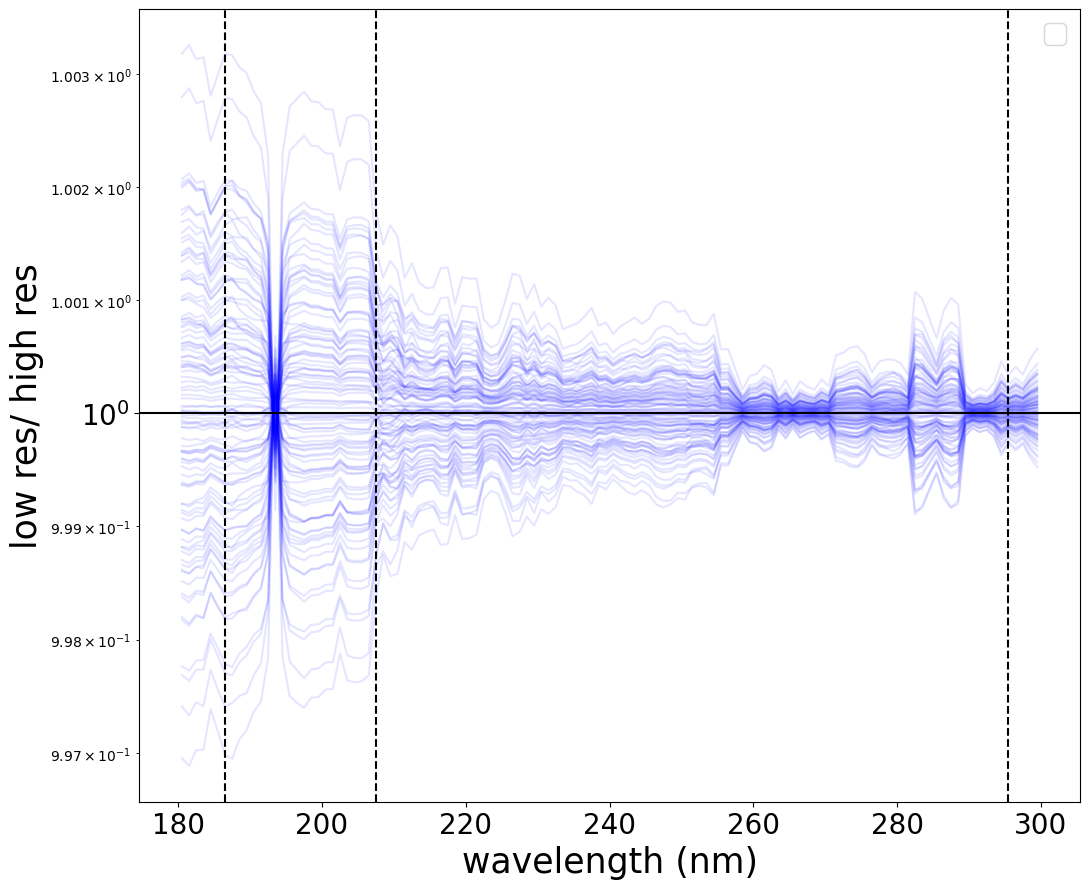

In [21]:
fig4 = plt.figure(figsize=(11,9))
ax4 = fig4.add_subplot(111)
#ax4.plot(w, aveztSSD1,color='black')




ax4.plot(w, all_results['res_test_phot1_fac6_healpix256']['fac']/all_results['res_test_phot1_fac6_healpix1024']['fac'], color='blue', alpha=0.1)




plt.axvline(x=186.5, color='black', linestyle='--')
plt.axvline(x=207.5, color='black', linestyle='--')
plt.axvline(x=295.5, color='black', linestyle='--')
plt.axhline(y=1, color='black')
plt.legend(fontsize=20, ncols=2)
ax4.set_yscale('log')
ax4.set_ylabel(r'low res/ high res',size=25)
#ax4.set_title(r'K star ', size=20)
ax4.set_xlabel(r'wavelength (nm)', size=25)
ax4.tick_params(axis='both', labelsize = 20)
plt.tight_layout()
fig4.savefig(fd +'facular ratio'+'.png', transparent=False)


/var/tmp/pbs.2800432.pbs-7/ipykernel_674702/3615067751.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=20, ncols=2)


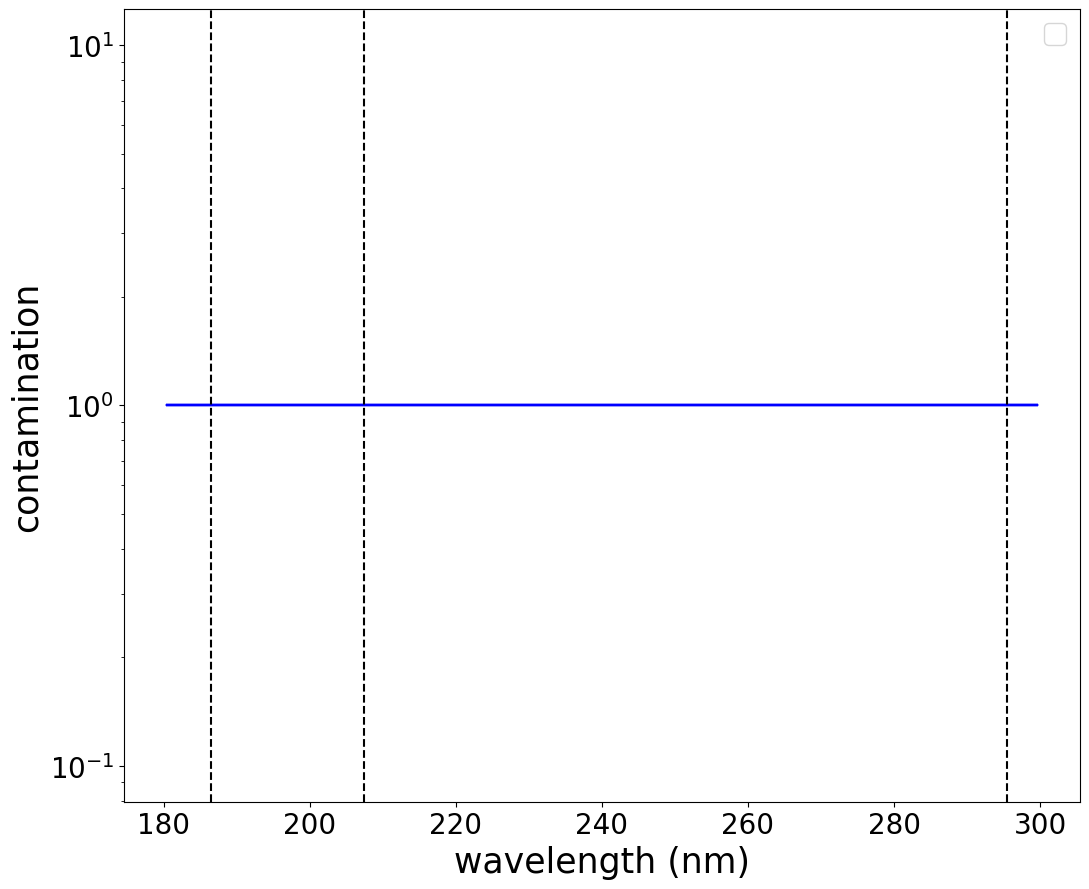

In [15]:
fig4 = plt.figure(figsize=(11,9))
ax4 = fig4.add_subplot(111)
#ax4.plot(w, aveztSSD1,color='black')




ax4.plot(w, all_results['res_test_phot1_fac6_healpix256']['quiet']/all_results['res_test_phot1_fac6_healpix1024']['quiet'], color='blue', alpha=0.1)




plt.axvline(x=186.5, color='black', linestyle='--')
plt.axvline(x=207.5, color='black', linestyle='--')
plt.axvline(x=295.5, color='black', linestyle='--')
plt.legend(fontsize=20, ncols=2)
ax4.set_yscale('log')
ax4.set_ylabel(r'contamination',size=25)
#ax4.set_title(r'K star ', size=20)
ax4.set_xlabel(r'wavelength (nm)', size=25)
ax4.tick_params(axis='both', labelsize = 20)
plt.tight_layout()
fig4.savefig(fd +'facular ratio'+'.png', transparent=False)


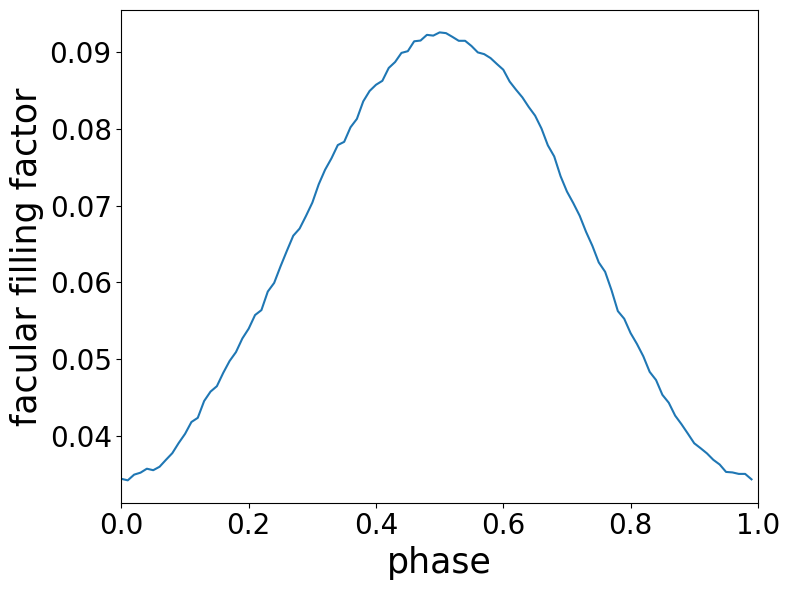

In [63]:
fig5 = plt.figure(figsize=(8,6))
ax5 = fig5.add_subplot(111)


ff_phase = all_results['batch_phot1_fac3']['ff_phase']


phase = np.linspace(0, 1, ff_phase.shape[1], endpoint=False)

ax5.plot(phase, ff_phase[0])  # pick one wavelength
ax5.set_xlabel('phase',size=25)
ax5.set_ylabel('facular filling factor',size=25)

ax5.set_xlim(0,1)


ax5.tick_params(axis='both', labelsize = 20)
plt.tight_layout()
fig5.savefig(fd +'phase_fill_factor'+'.png', transparent=False)


In [ ]:
#plt.plot(np.arange(120)+180.5, np.mean(epsilon_2D,axis=1))

In [ ]:
#plt.plot(np.arange(120)+180.5, np.mean(contrast_2D,axis=1))

In [49]:
ff_phase = all_results['batch_phot1_fac3']['ff_phase']
np.linspace(0, 1, ff_phase.shape[1], endpoint=False)

array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99])